In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"lorenz_data_with_missing_and_region.csv")
df

,x,y,z,region
0,0.000000,1.000000,1.050000,Right
1,0.100000,0.990000,1.022000,Right
2,0.189000,1.007078,0.995737,Right
3,0.270808,1.048045,0.971087,Right
4,0.348532,1.110761,0.948030,Right
...,...,...,...,...
9995,-1.616816,-2.741445,17.036311,Left
9996,-1.729279,-2.891293,16.626334,Left
9997,-1.845481,-3.059062,16.232963,Left
9998,-1.966839,-3.245630,15.856539,Left


In [2]:
df.head()

,x,y,z,region
0,0.000000,1.000000,1.050000,Right
1,0.100000,0.990000,1.022000,Right
2,0.189000,1.007078,0.995737,Right
3,0.270808,1.048045,0.971087,Right
4,0.348532,1.110761,0.948030,Right


In [3]:
df.tail()

,x,y,z,region
9995,-1.616816,-2.741445,17.036311,Left
9996,-1.729279,-2.891293,16.626334,Left
9997,-1.845481,-3.059062,16.232963,Left
9998,-1.966839,-3.245630,15.856539,Left
9999,-2.094718,-3.452016,15.497534,Left


In [4]:
df.dtypes

x         float64
y         float64
z         float64
region     object
dtype: object

In [5]:
df.isna().sum()

x         100
y         100
z         100
region      0
dtype: int64

In [6]:
df.describe()

,x,y,z
count,9900.000000,9900.000000,9900.000000
mean,0.873167,0.870171,25.157849
std,8.200619,9.130574,7.645102
min,-18.920202,-24.787274,0.842527
25%,-6.357953,-6.353579,20.101029
50%,1.625719,1.644887,25.864533
75%,8.210134,8.278153,29.443718
max,21.274942,28.981041,53.717701


In [7]:
df1=df['region'].value_counts()
df1

region
Right    5448
Left     4552
Name: count, dtype: int64

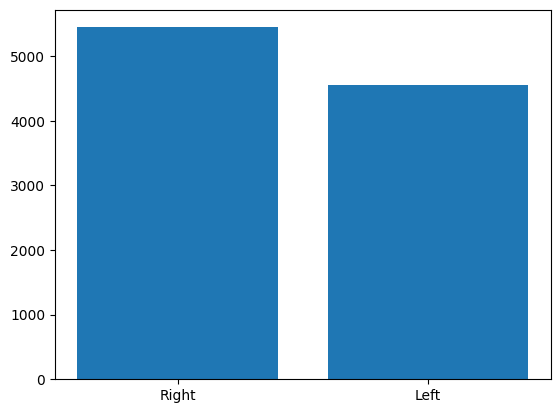

In [8]:
plt.bar(df1.index,df1.values)
plt.show()

In [9]:
h=df.corr(numeric_only=True)

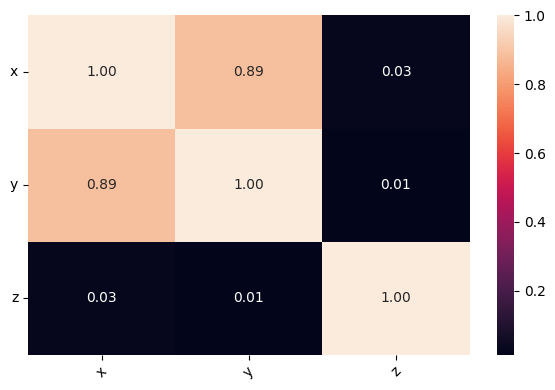

In [10]:
plt.figure(figsize=(6,4))
sns.heatmap(h,annot=True,fmt=".2f",)
annot_kws={'size':7}
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

<Axes: ylabel='z'>

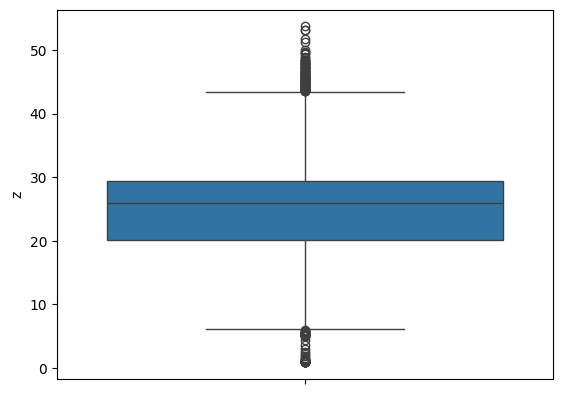

In [11]:
sns.boxplot(y='z',data=df)

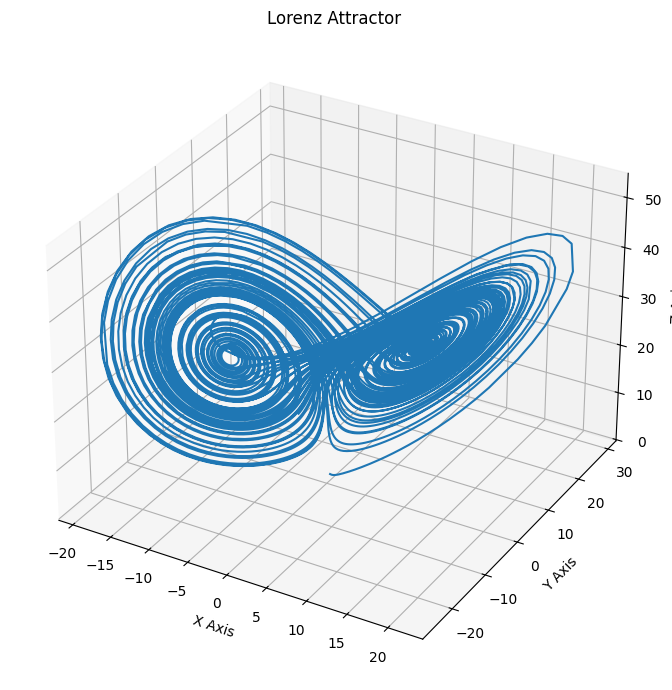

In [12]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


df_plot = df.dropna()

fig = plt.figure(figsize=(11,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(df_plot['x'], df_plot['y'], df_plot['z'])

ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')

ax.set_title('Lorenz Attractor')
plt.tight_layout()
plt.show()

In [13]:
df1=pd.get_dummies(df[['region']],dtype=int)
df1


,region_Left,region_Right
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1
...,...,...
9995,1,0
9996,1,0
9997,1,0
9998,1,0


In [14]:
dfe=pd.concat([df,df1],axis=1)
dfe

,x,y,z,region,region_Left,region_Right
0,0.000000,1.000000,1.050000,Right,0,1
1,0.100000,0.990000,1.022000,Right,0,1
2,0.189000,1.007078,0.995737,Right,0,1
3,0.270808,1.048045,0.971087,Right,0,1
4,0.348532,1.110761,0.948030,Right,0,1
...,...,...,...,...,...,...
9995,-1.616816,-2.741445,17.036311,Left,1,0
9996,-1.729279,-2.891293,16.626334,Left,1,0
9997,-1.845481,-3.059062,16.232963,Left,1,0
9998,-1.966839,-3.245630,15.856539,Left,1,0


In [15]:
dfe.drop(columns=['region'],inplace=True)
dfe

,x,y,z,region_Left,region_Right
0,0.000000,1.000000,1.050000,0,1
1,0.100000,0.990000,1.022000,0,1
2,0.189000,1.007078,0.995737,0,1
3,0.270808,1.048045,0.971087,0,1
4,0.348532,1.110761,0.948030,0,1
...,...,...,...,...,...
9995,-1.616816,-2.741445,17.036311,1,0
9996,-1.729279,-2.891293,16.626334,1,0
9997,-1.845481,-3.059062,16.232963,1,0
9998,-1.966839,-3.245630,15.856539,1,0


In [16]:
dfe['x_next'] = dfe['x'].shift(-1)
dfe['y_next'] = dfe['y'].shift(-1)
dfe['z_next'] = dfe['z'].shift(-1)

dfe.dropna(inplace=True)
dfe

,x,y,z,region_Left,region_Right,x_next,y_next,z_next
0,0.000000,1.000000,1.050000,0,1,0.100000,0.990000,1.022000
1,0.100000,0.990000,1.022000,0,1,0.189000,1.007078,0.995737
2,0.189000,1.007078,0.995737,0,1,0.270808,1.048045,0.971087
3,0.270808,1.048045,0.971087,0,1,0.348532,1.110761,0.948030
4,0.348532,1.110761,0.948030,0,1,0.424755,1.193938,0.926620
...,...,...,...,...,...,...,...,...
9994,-1.506599,-2.608777,17.462679,1,0,-1.616816,-2.741445,17.036311
9995,-1.616816,-2.741445,17.036311,1,0,-1.729279,-2.891293,16.626334
9996,-1.729279,-2.891293,16.626334,1,0,-1.845481,-3.059062,16.232963
9997,-1.845481,-3.059062,16.232963,1,0,-1.966839,-3.245630,15.856539


In [17]:
dfe.dtypes

x               float64
y               float64
z               float64
region_Left       int64
region_Right      int64
x_next          float64
y_next          float64
z_next          float64
dtype: object

In [18]:
dfe['x'].unique()

array([ 0.        ,  0.1       ,  0.189     , ..., -1.72927927,
       -1.84548063, -1.96683881], shape=(9417,))

In [19]:
dfe['y'].unique()

array([ 1.        ,  0.99      ,  1.007078  , ..., -2.8912929 ,
       -3.05906243, -3.24563018], shape=(9417,))

In [20]:
dfe['z'].unique()

array([ 1.05      ,  1.022     ,  0.99573667, ..., 16.6263338 ,
       16.23296343, 15.85653881], shape=(9417,))

In [21]:
dfe['x'].fillna(dfe['x'].mean(), inplace=True)
dfe['y'].fillna(dfe['y'].mean(), inplace=True)
dfe['z'].fillna(dfe['z'].mean(), inplace=True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_13432\3824796964.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dfe['x'].fillna(dfe['x'].mean(), inplace=True)
C:\Users\ACER\AppData\Local\Temp\ipykernel_13432\3824796964.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [22]:
dfe.isna().sum()

x               0
y               0
z               0
region_Left     0
region_Right    0
x_next          0
y_next          0
z_next          0
dtype: int64

In [23]:
X=dfe[['x','y','z','region_Left','region_Right']]
X.ndim

2

In [24]:
X

,x,y,z,region_Left,region_Right
0,0.000000,1.000000,1.050000,0,1
1,0.100000,0.990000,1.022000,0,1
2,0.189000,1.007078,0.995737,0,1
3,0.270808,1.048045,0.971087,0,1
4,0.348532,1.110761,0.948030,0,1
...,...,...,...,...,...
9994,-1.506599,-2.608777,17.462679,1,0
9995,-1.616816,-2.741445,17.036311,1,0
9996,-1.729279,-2.891293,16.626334,1,0
9997,-1.845481,-3.059062,16.232963,1,0


In [25]:
Y=dfe[['x_next','y_next','z_next']]
Y.ndim

2

In [26]:
Y

,x_next,y_next,z_next
0,0.100000,0.990000,1.022000
1,0.189000,1.007078,0.995737
2,0.270808,1.048045,0.971087
3,0.348532,1.110761,0.948030
4,0.424755,1.193938,0.926620
...,...,...,...
9994,-1.616816,-2.741445,17.036311
9995,-1.729279,-2.891293,16.626334
9996,-1.845481,-3.059062,16.232963
9997,-1.966839,-3.245630,15.856539


In [27]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.30,shuffle=False)

In [28]:
# scaler_X = StandardScaler()
# x_train = scaler_X.fit_transform(x_train)
# x_test  = scaler_X.transform(x_test)

# scaler_y = StandardScaler()
# y_train = scaler_y.fit_transform(y_train)
# y_test  = scaler_y.transform(y_test)

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_percentage_error



models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}


results = {}


for name, model in models.items():

    
    model.fit(x_train, y_train)


    y_pred = model.predict(x_test)

    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape=mean_absolute_percentage_error(y_test,y_pred)

    
    results[name] = {"R2 Score": r2, "RMSE": rmse}

    
    print(f"{name}")
    print(f"R2 Score: {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE:{mape:.4f}")
    print("---------------------------")

Linear Regression
R2 Score: 0.9962
RMSE: 0.4852
MAPE:0.0458
---------------------------
Decision Tree
R2 Score: 0.9965
RMSE: 0.4908
MAPE:0.1345
---------------------------
Random Forest
R2 Score: 0.9995
RMSE: 0.1800
MAPE:0.0506
---------------------------
KNN
R2 Score: 0.9992
RMSE: 0.2393
MAPE:0.0972
---------------------------


In [30]:
from sklearn.model_selection import GridSearchCV
rf = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

In [31]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,              
    scoring='r2',
    n_jobs=-1          
)

grid_search.fit(x_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [32]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: 0.994784676263317


In [33]:
best_rf = grid_search.best_estimator_

# Evaluate on test set
train_r2 = best_rf.score(x_train, y_train)
test_r2 = best_rf.score(x_test, y_test)

print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train R2: 0.9999249098544444
Test R2: 0.999535738952737


In [34]:
y_pred = best_rf.predict(x_test)

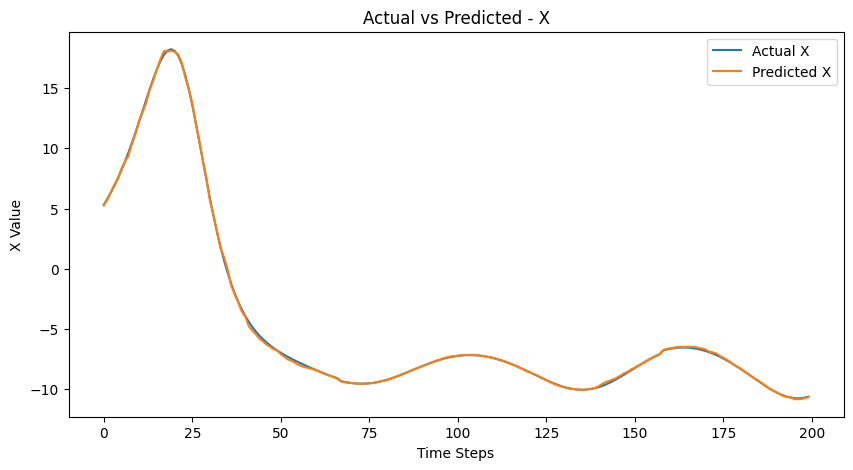

In [35]:
y_test_reset = y_test.reset_index(drop=True)

plt.figure(figsize=(10,5))

plt.plot(y_test_reset.iloc[:200, 0], label="Actual X")
plt.plot(y_pred[:200, 0], label="Predicted X")

plt.legend()
plt.xlabel("Time Steps")
plt.ylabel("X Value")
plt.title("Actual vs Predicted - X")
plt.show()

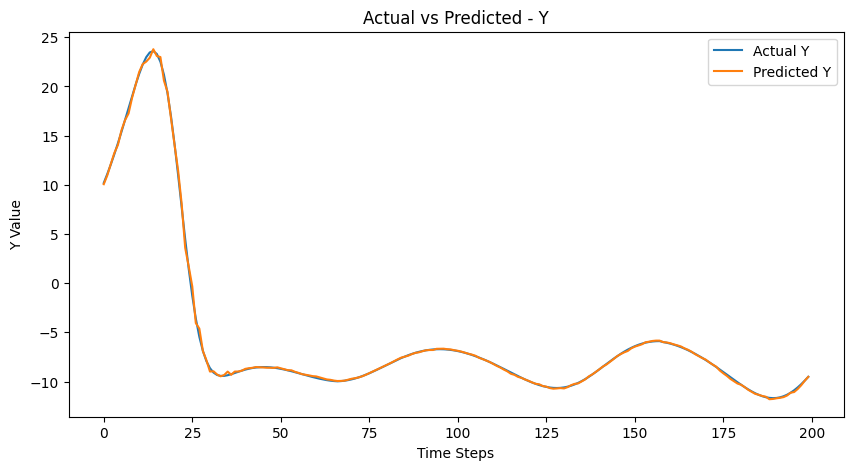

In [36]:
plt.figure(figsize=(10,5))

plt.plot(y_test_reset.iloc[:200, 1], label="Actual Y")
plt.plot(y_pred[:200, 1], label="Predicted Y")

plt.legend()
plt.xlabel("Time Steps")
plt.ylabel("Y Value")
plt.title("Actual vs Predicted - Y")
plt.show()

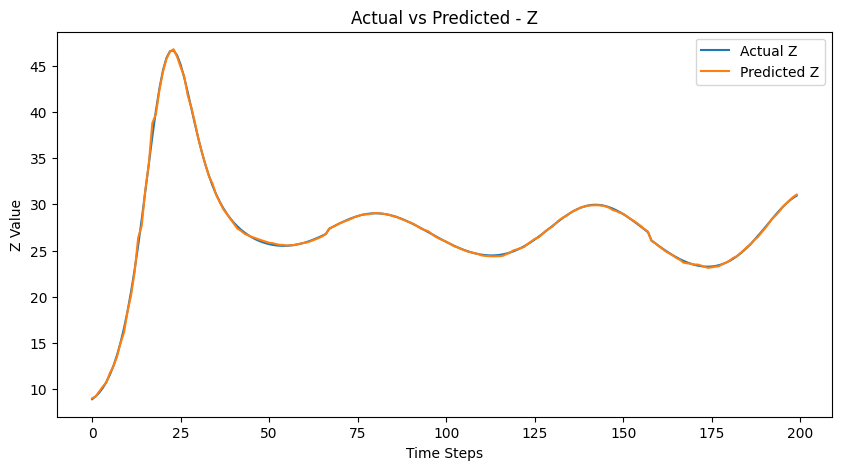

In [37]:
plt.figure(figsize=(10,5))

plt.plot(y_test_reset.iloc[:200, 2], label="Actual Z")
plt.plot(y_pred[:200, 2], label="Predicted Z")

plt.legend()
plt.title("Actual vs Predicted - Z")
plt.xlabel("Time Steps")
plt.ylabel("Z Value")
plt.show()

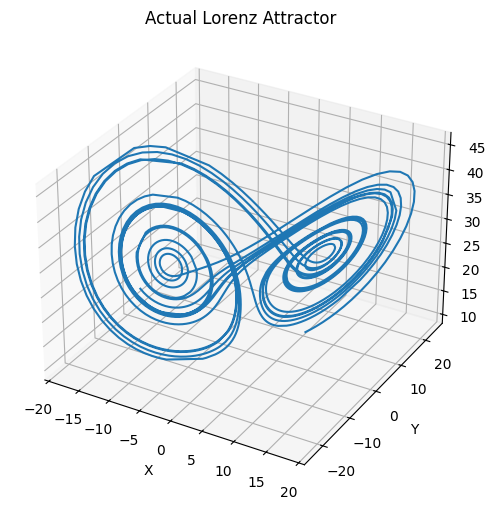

In [38]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(
    y_test_reset.iloc[:2000, 0],
    y_test_reset.iloc[:2000, 1],
    y_test_reset.iloc[:2000, 2]
)

ax.set_title("Actual Lorenz Attractor")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

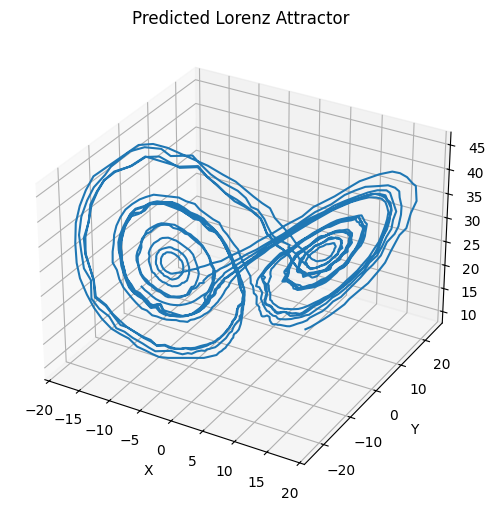

In [39]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(
    y_pred[:2000, 0],
    y_pred[:2000, 1],
    y_pred[:2000, 2]
)

ax.set_title("Predicted Lorenz Attractor")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

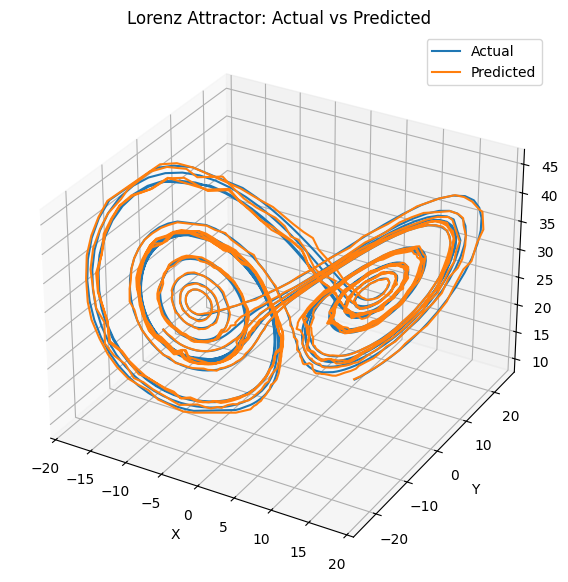

In [40]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# ---- Actual Lorenz ----
ax.plot(
    y_test_reset.iloc[:2000, 0],   # X
    y_test_reset.iloc[:2000, 1],   # Y
    y_test_reset.iloc[:2000, 2],   # Z
    label="Actual",
)

# ---- Predicted Lorenz ----
ax.plot(
    y_pred[:2000, 0], 
    y_pred[:2000, 1], 
    y_pred[:2000, 2], 
    label="Predicted",
)

ax.set_title("Lorenz Attractor: Actual vs Predicted")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.show()